In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# Transfer ResNet

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# ResNet is trained for images in a specific range

transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_train = datasets.STL10(root='data', split="train", download=True, transform=transformer) 
data_test = datasets.STL10(root='data', split="test", download=True, transform=transformer)   

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Data categories: {data_train.classes}")

Image batch shape: torch.Size([32, 3, 96, 96])
Label batch shape: torch.Size([32])
Data categories: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


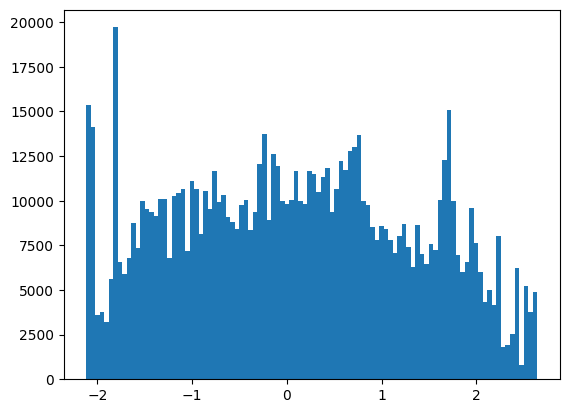

In [4]:
# pixel intensity values in the images
plt.hist(images.data.numpy().flatten(), 100);

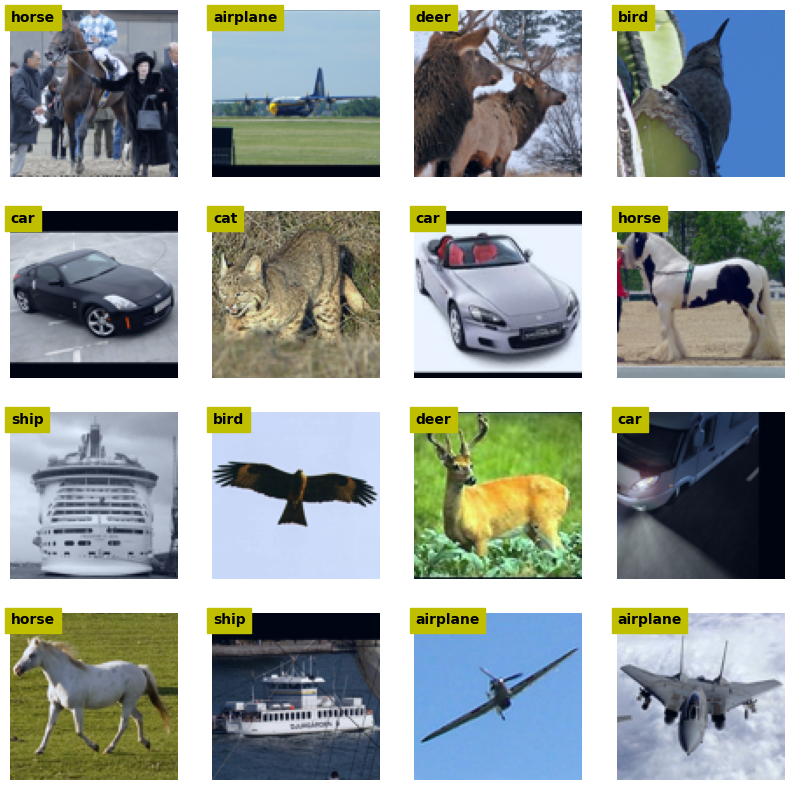

In [5]:
# inspect images

fig, axs = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axs.flatten()):
    
    pic = images.data[i].numpy().transpose((1,2,0))
    pic = pic -np.min(pic) # undo normalization
    pic = pic/np.max(pic)
    
    label = data_train.classes[labels[i]]
    
    ax.imshow(pic)
    ax.text(0, 0, label, ha="left", va="top", fontweight="bold", color="k", backgroundcolor="y")
    ax.axis("off")

In [9]:
resnet18 = torchvision.models.resnet18(pretrained=True)

for p in resnet18.parameters():
    p.requires_grad = False

# print(resnet18) # we can check that the last layer is called fc and it is Linear(512, 1000)
# out output is 10-way classification
resnet18.fc = nn.Linear(resnet18.fc.in_features, 10)

summary(resnet18.to(device), (3, 96, 96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 48, 48]           9,408
       BatchNorm2d-2           [-1, 64, 48, 48]             128
              ReLU-3           [-1, 64, 48, 48]               0
         MaxPool2d-4           [-1, 64, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          36,864
       BatchNorm2d-6           [-1, 64, 24, 24]             128
              ReLU-7           [-1, 64, 24, 24]               0
            Conv2d-8           [-1, 64, 24, 24]          36,864
       BatchNorm2d-9           [-1, 64, 24, 24]             128
             ReLU-10           [-1, 64, 24, 24]               0
       BasicBlock-11           [-1, 64, 24, 24]               0
           Conv2d-12           [-1, 64, 24, 24]          36,864
      BatchNorm2d-13           [-1, 64, 24, 24]             128
             ReLU-14           [-1, 64,

In [10]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [13]:
resnet18 = torchvision.models.resnet18(pretrained=True)

for p in resnet18.parameters():
    p.requires_grad = False

# print(resnet18) # we can check that the last layer is called fc and it is Linear(512, 1000)
# out output is 10-way classification
resnet18.fc = nn.Linear(resnet18.fc.in_features, 10)

resnet18.to(device);

loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(resnet18.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.AdamW(resnet18.parameters(), lr=0.001, weight_decay=0.01)
epochs = 10
losses, train_acc, test_acc = train(resnet18, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/10], Train Loss: 1.1799, Train Accuracy: 0.6182, Test Accuracy: 0.7416
Epoch [2/10], Train Loss: 0.7174, Train Accuracy: 0.7646, Test Accuracy: 0.7689
Epoch [3/10], Train Loss: 0.6369, Train Accuracy: 0.7889, Test Accuracy: 0.7768
Epoch [4/10], Train Loss: 0.5836, Train Accuracy: 0.8029, Test Accuracy: 0.7823
Epoch [5/10], Train Loss: 0.5513, Train Accuracy: 0.8153, Test Accuracy: 0.7792
Epoch [6/10], Train Loss: 0.5264, Train Accuracy: 0.8187, Test Accuracy: 0.7847
Epoch [7/10], Train Loss: 0.5176, Train Accuracy: 0.8197, Test Accuracy: 0.7875
Epoch [8/10], Train Loss: 0.5098, Train Accuracy: 0.8225, Test Accuracy: 0.7825
Epoch [9/10], Train Loss: 0.4866, Train Accuracy: 0.8355, Test Accuracy: 0.7857
Epoch [10/10], Train Loss: 0.4675, Train Accuracy: 0.8357, Test Accuracy: 0.7812


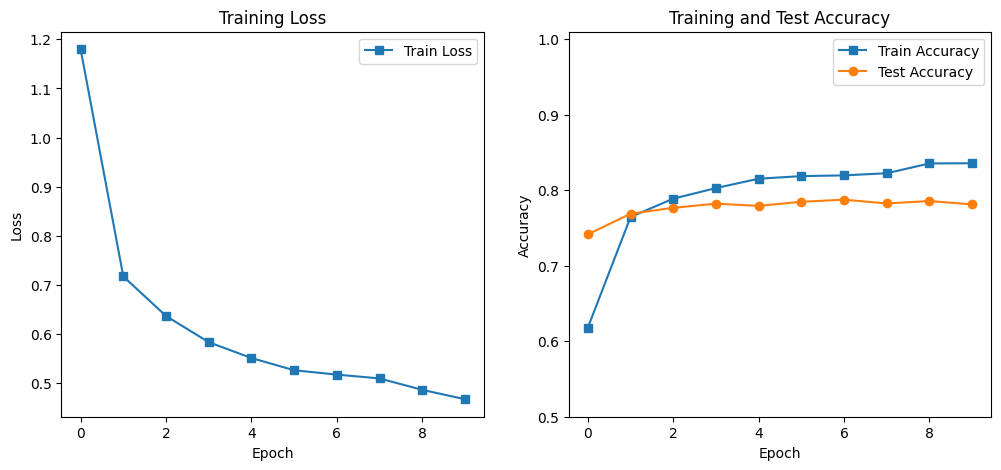

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_acc, "s-", label='Train Accuracy')
ax[1].plot(test_acc, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.5, 1.01)
ax[1].legend()

plt.show()

In [18]:
vgg16 = torchvision.models.vgg16(pretrained=True)

for p in vgg16.parameters():
    p.requires_grad = False

# print(vgg16) # we can check that the last layer is called is Linear(4096, 1000)
# out output is 10-way classification
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, 10)

summary(vgg16.to(device), (3, 96, 96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 96, 96]           1,792
              ReLU-2           [-1, 64, 96, 96]               0
            Conv2d-3           [-1, 64, 96, 96]          36,928
              ReLU-4           [-1, 64, 96, 96]               0
         MaxPool2d-5           [-1, 64, 48, 48]               0
            Conv2d-6          [-1, 128, 48, 48]          73,856
              ReLU-7          [-1, 128, 48, 48]               0
            Conv2d-8          [-1, 128, 48, 48]         147,584
              ReLU-9          [-1, 128, 48, 48]               0
        MaxPool2d-10          [-1, 128, 24, 24]               0
           Conv2d-11          [-1, 256, 24, 24]         295,168
             ReLU-12          [-1, 256, 24, 24]               0
           Conv2d-13          [-1, 256, 24, 24]         590,080
             ReLU-14          [-1, 256,

In [19]:
vgg16 = torchvision.models.vgg16(pretrained=True)

for p in vgg16.parameters():
    p.requires_grad = False

vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, 10)
vgg16.to(device);
loss_fn = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD(vgg16.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.AdamW(vgg16.parameters(), lr=0.001, weight_decay=0.01)
epochs = 5
losses, train_acc, test_acc = train(vgg16, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/5], Train Loss: 0.4432, Train Accuracy: 0.8558, Test Accuracy: 0.9101
Epoch [2/5], Train Loss: 0.2867, Train Accuracy: 0.9091, Test Accuracy: 0.9011
Epoch [3/5], Train Loss: 0.2339, Train Accuracy: 0.9243, Test Accuracy: 0.9062
Epoch [4/5], Train Loss: 0.2129, Train Accuracy: 0.9343, Test Accuracy: 0.9060
Epoch [5/5], Train Loss: 0.2042, Train Accuracy: 0.9353, Test Accuracy: 0.9124


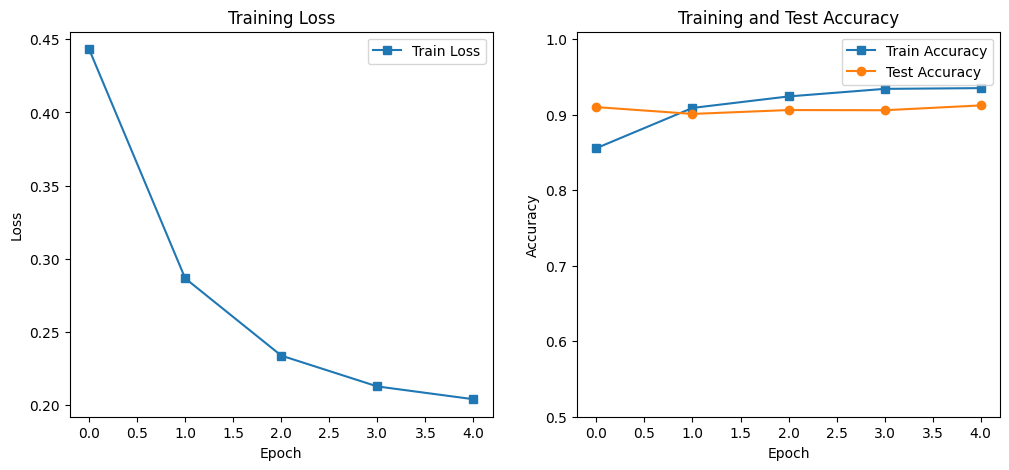

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_acc, "s-", label='Train Accuracy')
ax[1].plot(test_acc, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.5, 1.01)
ax[1].legend()

plt.show()

In [ ]:
# VGG16 gets a better performance compare to resnet18 in this particular dataset.
# for transfer learning is important not to apply just one pretrained network but several of them